# Week 8 - Regression Topics

# Error terms and residuals
## Quadratic scenario
## Confounder scenario
# Formula for standard error: sqrt(sigma**2 / (Var(X) * num_samples))
# Transforming X: ln(X + 1), sqrt, asinh, Winsorizing

## AI prompts for quadratic data

Prompt 1: Model diagnostics before launch.

"I’m preparing to deploy a sales forecasting model for our campus coffee cart. The overall test RMSE looks acceptable, but the **residuals** are consistently positive on high-promotion days and negative on low-promotion days. What diagnostic plots and model changes should I try before deciding whether this model is safe to use for staffing decisions?

Prompt 2: Simulation / synthetic data

"I’m generating synthetic coffee cart data where the true sales curve is quadratic in flyers and the **error term** is Gaussian with mean zero and constant variance. Can you help me write Python code to simulate the data and then show how residuals change when I fit the wrong linear model?"

Prompt 3: Heteroskedasticity in the DGP

Suppose the true **error term's** variance increases on high-traffic campus days, even after controlling for flyers. How would heteroskedastic errors affect inference for the flyer coefficient, and what robust standard errors or modeling changes should I consider?

Prompt 4: Choosing between two production models

I have two models for predicting daily coffee demand: a simple linear regression and a gradient boosting model. The gradient boosting model has lower test error overall, but its **residuals** are less stable across different ranges of promotional spending. How should I compare these models if the business goal is to avoid running out of coffee?

# Goal: understand the ways in which error terms and residuals can be biased.

Story:

A small campus coffee cart tracks daily sales.

X is the number of promotional flyers handed out that morning.

Y is the number of cups of coffee sold that day.

# Quadratic scenario:

## Assume the first equation below is the DGP that defines Y.

# Ways of defining error term relative to the DGP:

## 1. Y = intercept + beta * X + beta_quad * X**2 + err_standard_normal

## 2. Y = intercept + beta * X + err_quadratic

# Way of defining models:

## 3. Y = intercept_hat_1 + beta_hat_1 * X + beta_quad_hat_1 * X**2 + residual_1

## 4. Y = intercept_hat_2 + beta_hat_2 * X + residual_2

# Question 1: Which one is the correct error term, err_standard_normal or err_quadratic?

# Question 2: is err_standard_normal zero on average?  Is it correlated with X?

# Question 3: is err_quadratic zero on average?  Is it correlated with X?

# Question 4: Is residual_1 the same as one or both of the error terms?

# Question 5: Is residual_2 the same as one or both of the error terms?


True DGP parameters
-------------------
intercept     = 20
beta          = 1.5
beta_squared  = 0.04

Estimated quadratic model
-------------------------
intercept_hat_1     = 20.2520
beta_hat_1          = 1.4802
beta_squared_hat_1  = 0.0404

Estimated linear-only model
---------------------------
intercept_hat_2  = 4.1121
beta_hat_2       = 3.4849

Means and correlations with X
-----------------------------
              quantity          mean  correlation_with_X
0  err_standard_normal  6.741427e-02       -2.375791e-02
1        err_quadratic  3.214623e+01        9.693759e-01
2           residual_1 -9.698908e-15       -1.347577e-15
3           residual_2  2.842171e-16       -7.679646e-16


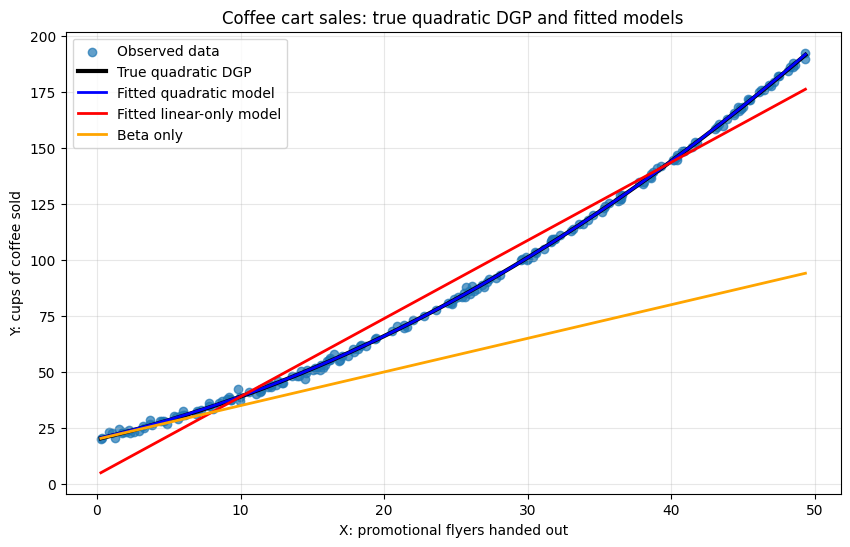

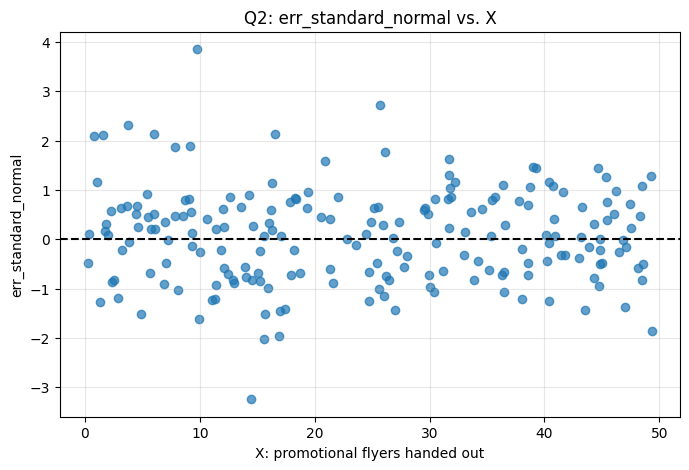

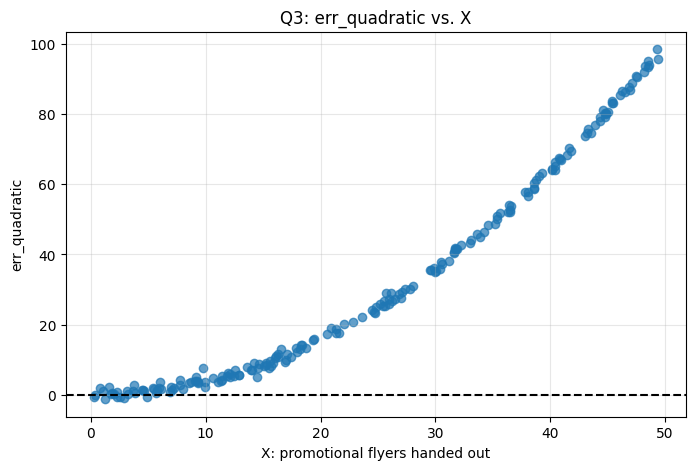

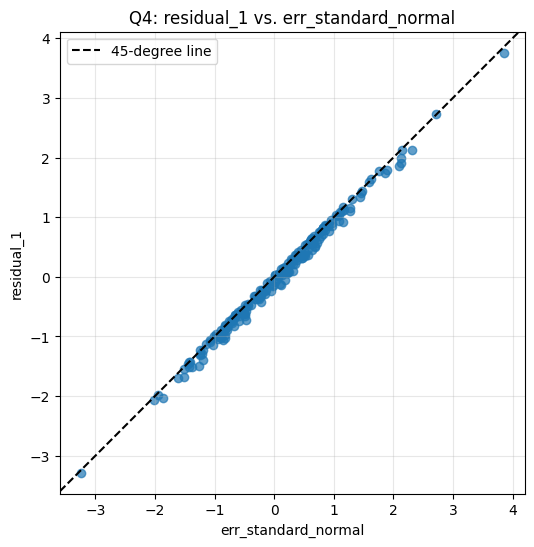

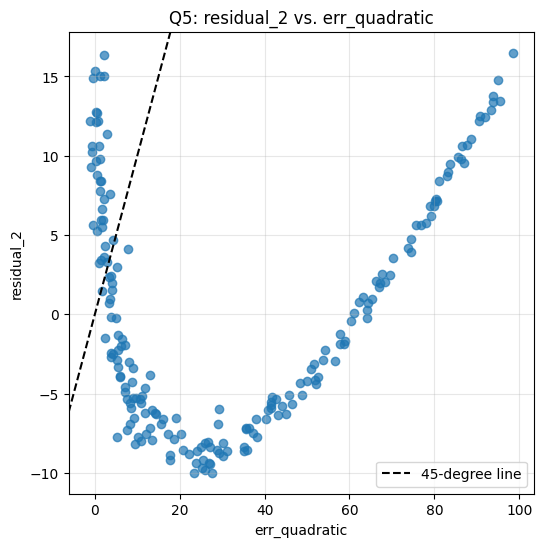

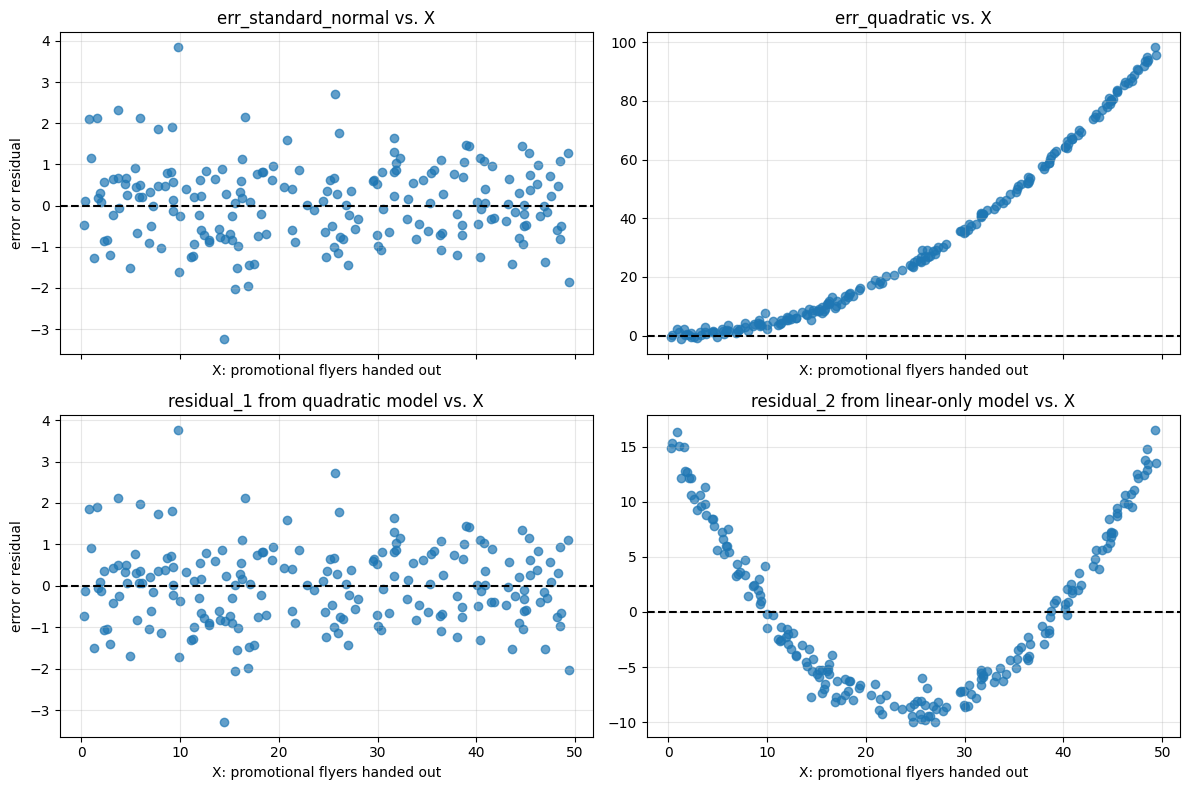

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

"""
Goal: understand the ways in which errors and residuals can be biased.

Story:
A small campus coffee cart tracks daily sales.

X is the number of promotional flyers handed out that morning.
Y is the number of cups of coffee sold that day.

Quadratic DGP:
Y = intercept + beta * X + beta_squared * X**2 + err_standard_normal
"""

# -----------------------------
# 1. Simulate the coffee cart DGP
# -----------------------------

np.random.seed(42)

n_days = 200

intercept = 20
beta = 1.5
beta_squared = 0.04

X = np.random.uniform(0, 50, size=n_days)

err_standard_normal = np.random.normal(loc=0, scale=1, size=n_days)

Y = intercept + beta * X + beta_squared * X**2 + err_standard_normal

# ----------------------------------------------------------
# 2. Define another "error" by leaving out the quadratic term
# ----------------------------------------------------------

# From:
# Y = intercept + beta * X + err_quadratic
#
# Therefore:
# err_quadratic = Y - intercept - beta * X

err_quadratic = Y - intercept - beta * X

# Since the true DGP is:
# Y = intercept + beta * X + beta_squared * X**2 + err_standard_normal
#
# this means:
# err_quadratic = beta_squared * X**2 + err_standard_normal

# ---------------------------------------------
# 3. Fit two models: quadratic and linear only
# ---------------------------------------------

# Model 1:
# Y = intercept_hat_1 + beta_hat_1 * X + beta_squared_hat_1 * X**2 + residual_1

X_quadratic = np.column_stack([X, X**2])

model_1 = LinearRegression()
model_1.fit(X_quadratic, Y)

Y_hat_1 = model_1.predict(X_quadratic)
residual_1 = Y - Y_hat_1

intercept_hat_1 = model_1.intercept_
beta_hat_1 = model_1.coef_[0]
beta_squared_hat_1 = model_1.coef_[1]

# Model 2:
# Y = intercept_hat_2 + beta_hat_2 * X + residual_2

X_linear = X.reshape(-1, 1)

model_2 = LinearRegression()
model_2.fit(X_linear, Y)

Y_hat_2 = model_2.predict(X_linear)
residual_2 = Y - Y_hat_2

intercept_hat_2 = model_2.intercept_
beta_hat_2 = model_2.coef_[0]

# -----------------------------
# 4. Summaries
# -----------------------------

summary = pd.DataFrame(
    {
        "quantity": [
            "err_standard_normal",
            "err_quadratic",
            "residual_1",
            "residual_2",
        ],
        "mean": [
            np.mean(err_standard_normal),
            np.mean(err_quadratic),
            np.mean(residual_1),
            np.mean(residual_2),
        ],
        "correlation_with_X": [
            np.corrcoef(X, err_standard_normal)[0, 1],
            np.corrcoef(X, err_quadratic)[0, 1],
            np.corrcoef(X, residual_1)[0, 1],
            np.corrcoef(X, residual_2)[0, 1],
        ],
    }
)

print()
print("True DGP parameters")
print("-------------------")
print(f"intercept     = {intercept}")
print(f"beta          = {beta}")
print(f"beta_squared  = {beta_squared}")

print()
print("Estimated quadratic model")
print("-------------------------")
print(f"intercept_hat_1     = {intercept_hat_1:.4f}")
print(f"beta_hat_1          = {beta_hat_1:.4f}")
print(f"beta_squared_hat_1  = {beta_squared_hat_1:.4f}")

print()
print("Estimated linear-only model")
print("---------------------------")
print(f"intercept_hat_2  = {intercept_hat_2:.4f}")
print(f"beta_hat_2       = {beta_hat_2:.4f}")

print()
print("Means and correlations with X")
print("-----------------------------")
print(summary)

# -----------------------------
# 5. Visualize the data and fits
# -----------------------------

X_grid = np.linspace(X.min(), X.max(), 300)

true_curve = intercept + beta * X_grid + beta_squared * X_grid**2
quadratic_fit = (
    intercept_hat_1
    + beta_hat_1 * X_grid
    + beta_squared_hat_1 * X_grid**2
)
linear_fit = intercept_hat_2 + beta_hat_2 * X_grid
beta_only = intercept + beta * X_grid

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.7, label="Observed data")
plt.plot(X_grid, true_curve, color="black", linewidth=3, label="True quadratic DGP")
plt.plot(X_grid, quadratic_fit, color="blue", linewidth=2, label="Fitted quadratic model")
plt.plot(X_grid, linear_fit, color="red", linewidth=2, label="Fitted linear-only model")
plt.plot(X_grid, beta_only, color="orange", linewidth=2, label="Beta only")
plt.xlabel("X: promotional flyers handed out")
plt.ylabel("Y: cups of coffee sold")
plt.title("Coffee cart sales: true quadratic DGP and fitted models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------
# Q2: Is err_standard_normal zero on average?
#     Is it correlated with X?
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(X, err_standard_normal, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("X: promotional flyers handed out")
plt.ylabel("err_standard_normal")
plt.title("Q2: err_standard_normal vs. X")
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------
# Q3: Is err_quadratic zero on average?
#     Is it correlated with X?
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(X, err_quadratic, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("X: promotional flyers handed out")
plt.ylabel("err_quadratic")
plt.title("Q3: err_quadratic vs. X")
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------
# Q4: Is residual_1 the same as err_standard_normal?
# ----------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(err_standard_normal, residual_1, alpha=0.7)
plt.axline((0, 0), slope=1, color="black", linestyle="--", label="45-degree line")
plt.xlabel("err_standard_normal")
plt.ylabel("residual_1")
plt.title("Q4: residual_1 vs. err_standard_normal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------
# Q5: Is residual_2 the same as err_quadratic?
# ----------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(err_quadratic, residual_2, alpha=0.7)
plt.axline((0, 0), slope=1, color="black", linestyle="--", label="45-degree line")
plt.xlabel("err_quadratic")
plt.ylabel("residual_2")
plt.title("Q5: residual_2 vs. err_quadratic")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------
# Optional: compare all four quantities against X
# ----------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0, 0].scatter(X, err_standard_normal, alpha=0.7)
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_title("err_standard_normal vs. X")

axes[0, 1].scatter(X, err_quadratic, alpha=0.7)
axes[0, 1].axhline(0, color="black", linestyle="--")
axes[0, 1].set_title("err_quadratic vs. X")

axes[1, 0].scatter(X, residual_1, alpha=0.7)
axes[1, 0].axhline(0, color="black", linestyle="--")
axes[1, 0].set_title("residual_1 from quadratic model vs. X")

axes[1, 1].scatter(X, residual_2, alpha=0.7)
axes[1, 1].axhline(0, color="black", linestyle="--")
axes[1, 1].set_title("residual_2 from linear-only model vs. X")

for ax in axes.ravel():
    ax.set_xlabel("X: promotional flyers handed out")
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("error or residual")
axes[1, 0].set_ylabel("error or residual")

plt.tight_layout()
plt.show()

## AI Prompts for confounded example

1. Synthetic data simulation

I’m creating a synthetic coffee cart dataset to test whether a regression model can recover the causal effect of flyers on sales when rainfall is a confounder. Please generate Python code where rainfall affects both flyers and sales, and where the true sales equation has a stored **error term** drawn from a standard normal distribution.

2. Residual diagnostic plot

I fit a model predicting coffee sales from flyers only. Can you help me make **residual** plots against rainfall and flyer count to check whether the model is systematically overpredicting or underpredicting on rainy mornings?

Story:

A small campus coffee cart tracks daily sales.

X is the number of promotional flyers handed out that morning.

Y is the number of cups of coffee sold that day.

W is the rainfall that morning, which decreases both X and Y.

# Confounder scenario:

## Assume the first equation below is the DGP that defines Y.

# Ways of defining error term relative to the DGP:


## 1. Y = intercept + beta * X + alpha * W + err_standard_normal

## 1.b. X = another_intercept + gamma * W + another_err

## 2. Y = intercept + beta * X + err_only_X

# Way of defining models:

## 3. Y = intercept_1_hat + beta_1_hat * X + alpha_1_hat * W + residual_1

## 4. Y = intercept_2_hat + beta_2_hat * X + residual_2

# Question 1: Which is the correct error term, err_standard_normal or err_only_X?

# Question 2: Is err_standard_normal zero on average? Is it correlated with X?

# Question 3: Is err_only_X zero on average? Is it correlated with X?

# Question 4: Is residual_1 the same as one or both of the error terms?

# Question 5: Is residual_2 the same as one or both of the error terms?


Story
-----
A small campus coffee cart tracks daily sales.
X = number of promotional flyers handed out that morning.
Y = number of cups of coffee sold that day.
W = rainfall that morning, which decreases both X and Y.

True DGP
--------
Y = intercept + beta * X + alpha * W + err_standard_normal

intercept = 40
beta      = 2.0
alpha     = -8.0

Alternative error definition
----------------------------
Y = intercept + beta * X + err_only_X
Therefore:
err_only_X = alpha * W + err_standard_normal

Estimated Model 1: includes X and W
-----------------------------------
Y = intercept_1_hat + beta_1_hat * X + alpha_1_hat * W + residual_1
intercept_1_hat = 40.1031
beta_1_hat      = 1.9997
alpha_1_hat     = -7.9207

Estimated Model 2: includes X only and omits W
----------------------------------------------
Y = intercept_2_hat + beta_2_hat * X + residual_2
intercept_2_hat = 16.7800
beta_2_hat      = 2.2834

Question 1
----------
Which is the correct error, err_standard_normal or err_only_X?



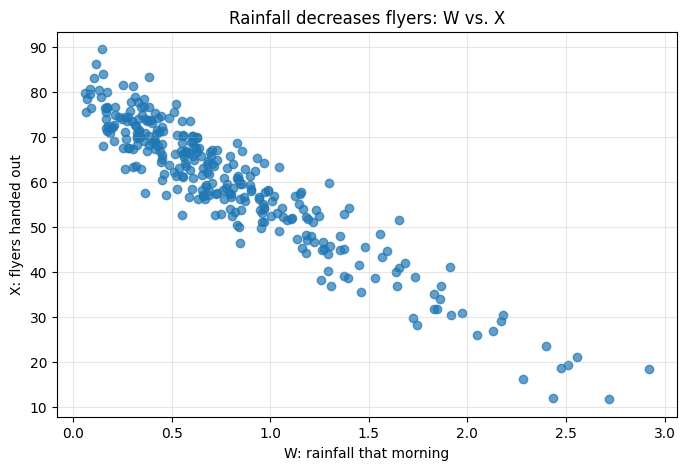

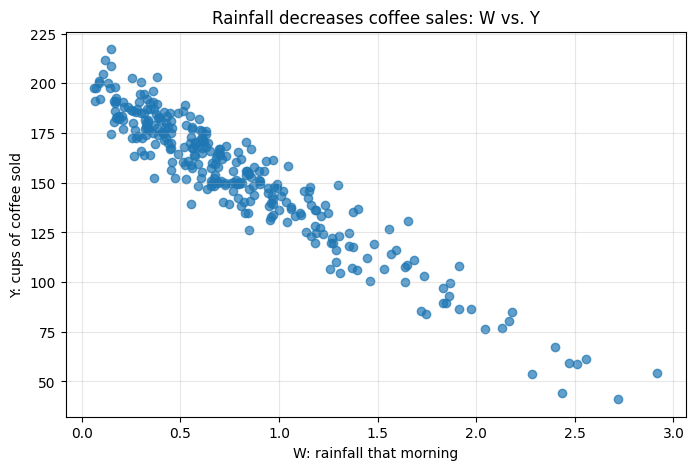

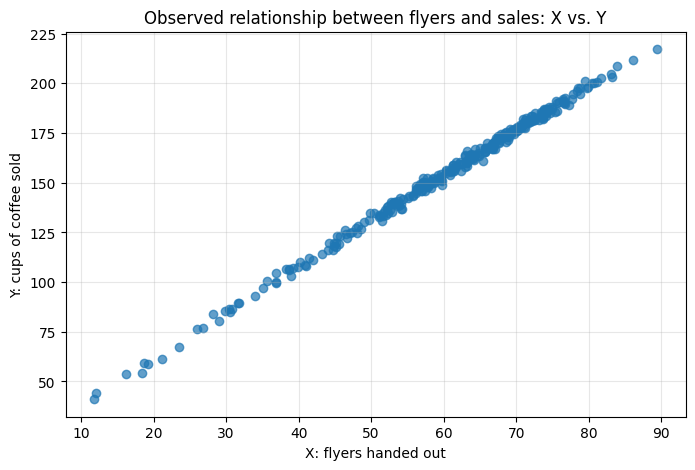

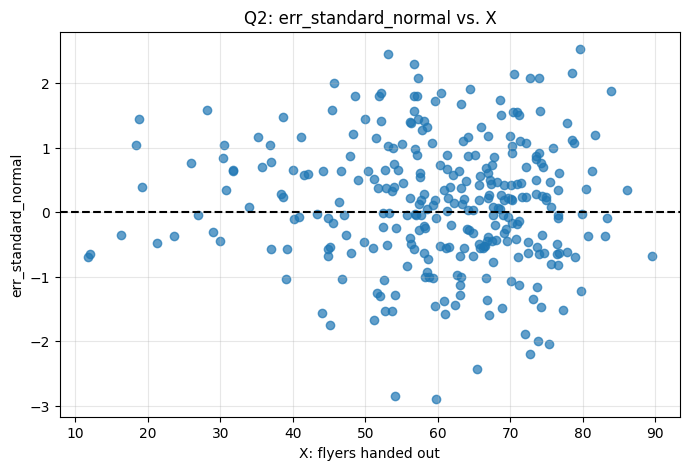

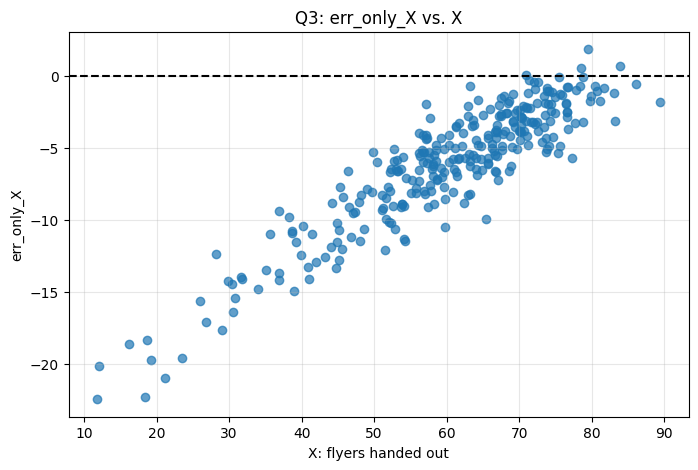

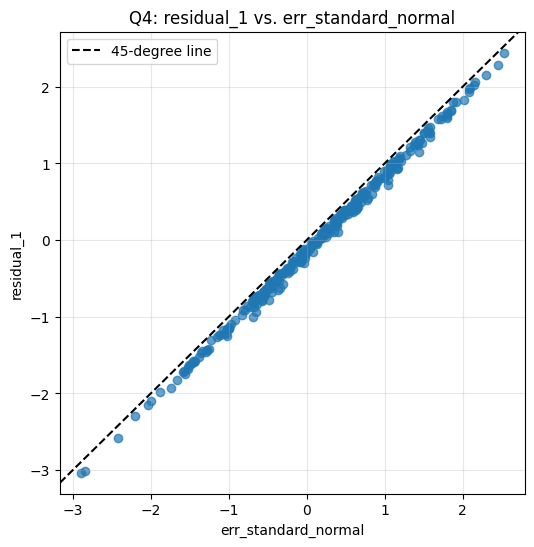

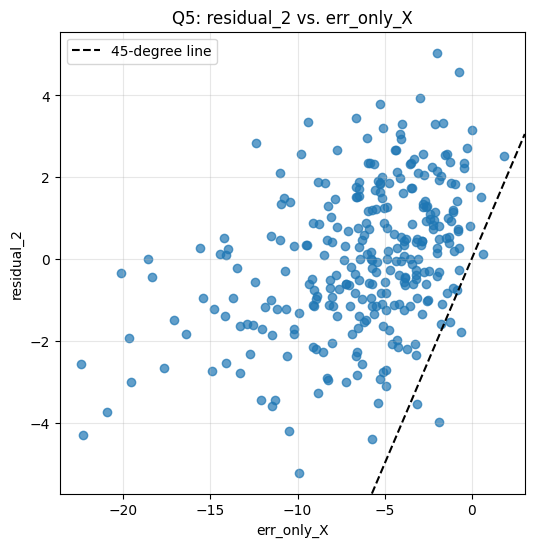

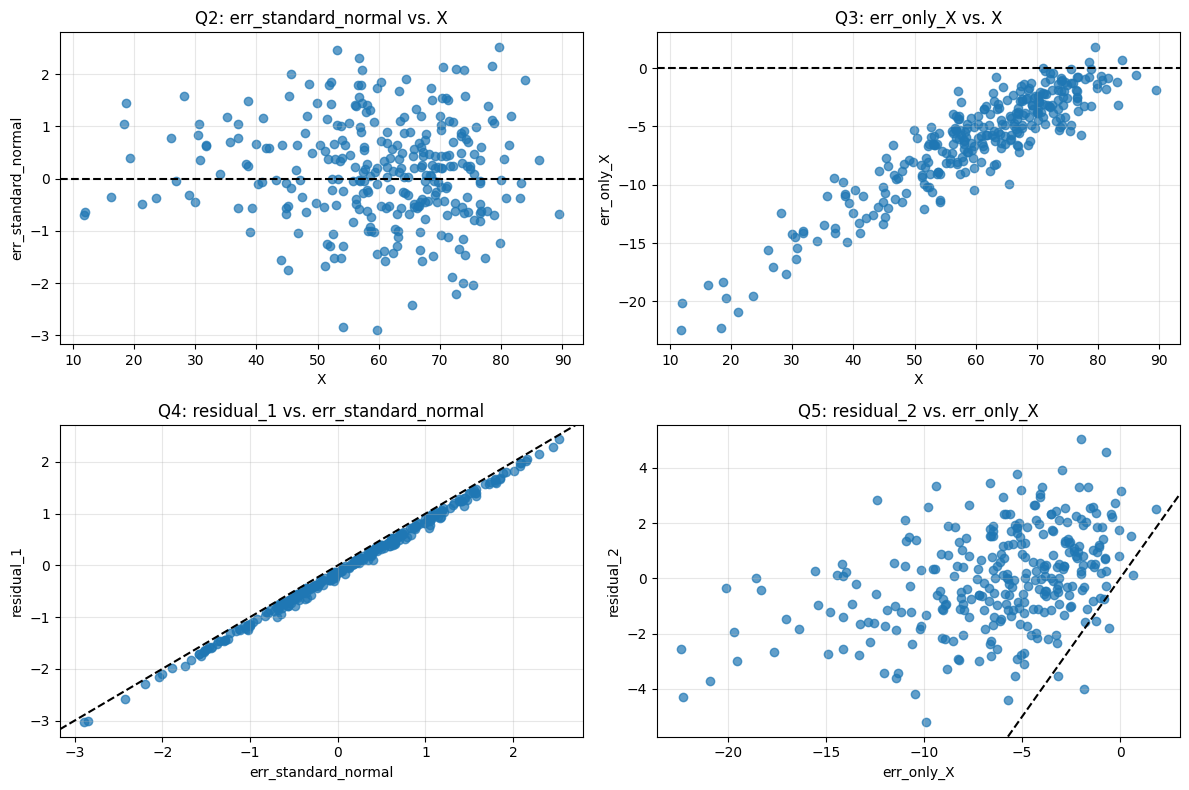

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

"""
Story:

A small campus coffee cart tracks daily sales.

X is the number of promotional flyers handed out that morning.
Y is the number of cups of coffee sold that day.
W is the rainfall that morning, which decreases both X and Y.

Confounder scenario:

True DGP:
Y = intercept + beta * X + alpha * W + err_standard_normal

Alternative way to define the error:
Y = intercept + beta * X + err_only_X

Therefore:
err_only_X = alpha * W + err_standard_normal

Models:

1. Correctly specified model:
Y = intercept_1_hat + beta_1_hat * X + alpha_1_hat * W + residual_1

2. Misspecified model that omits W:
Y = intercept_2_hat + beta_2_hat * X + residual_2
"""

# -----------------------------
# 1. Simulate the coffee cart DGP
# -----------------------------

np.random.seed(42)

n_days = 300

intercept = 40
beta = 2.0
alpha = -8.0

# W is rainfall in inches.
# Rainfall is positive and right-skewed.
W = np.random.gamma(shape=2.0, scale=0.4, size=n_days)

# X is the number of flyers handed out.
# Rain reduces flyer distribution.
flyer_noise = np.random.normal(loc=0, scale=5, size=n_days)
X = 80 - 25 * W + flyer_noise

# Keep X realistic: flyers cannot be negative.
X = np.clip(X, 0, None)

# Standard normal error.
err_standard_normal = np.random.normal(loc=0, scale=1, size=n_days)

# True DGP for Y.
# Rainfall directly decreases coffee sales because fewer people walk around campus.
Y = intercept + beta * X + alpha * W + err_standard_normal

# Alternative error when W is omitted from the pattern.
# From:
# Y = intercept + beta * X + err_only_X
#
# Therefore:
# err_only_X = Y - intercept - beta * X
#            = alpha * W + err_standard_normal

err_only_X = Y - intercept - beta * X

# -----------------------------
# 2. Fit the two models
# -----------------------------

# Model 1 includes both X and W.
# Y = intercept_1_hat + beta_1_hat * X + alpha_1_hat * W + residual_1

features_model_1 = np.column_stack([X, W])

model_1 = LinearRegression()
model_1.fit(features_model_1, Y)

Y_hat_1 = model_1.predict(features_model_1)
residual_1 = Y - Y_hat_1

intercept_1_hat = model_1.intercept_
beta_1_hat = model_1.coef_[0]
alpha_1_hat = model_1.coef_[1]

# Model 2 includes only X and omits W.
# Y = intercept_2_hat + beta_2_hat * X + residual_2

features_model_2 = X.reshape(-1, 1)

model_2 = LinearRegression()
model_2.fit(features_model_2, Y)

Y_hat_2 = model_2.predict(features_model_2)
residual_2 = Y - Y_hat_2

intercept_2_hat = model_2.intercept_
beta_2_hat = model_2.coef_[0]

# -----------------------------
# 3. Print explanatory answers
# -----------------------------

print()
print("Story")
print("-----")
print("A small campus coffee cart tracks daily sales.")
print("X = number of promotional flyers handed out that morning.")
print("Y = number of cups of coffee sold that day.")
print("W = rainfall that morning, which decreases both X and Y.")

print()
print("True DGP")
print("--------")
print("Y = intercept + beta * X + alpha * W + err_standard_normal")
print()
print(f"intercept = {intercept}")
print(f"beta      = {beta}")
print(f"alpha     = {alpha}")

print()
print("Alternative error definition")
print("----------------------------")
print("Y = intercept + beta * X + err_only_X")
print("Therefore:")
print("err_only_X = alpha * W + err_standard_normal")

print()
print("Estimated Model 1: includes X and W")
print("-----------------------------------")
print("Y = intercept_1_hat + beta_1_hat * X + alpha_1_hat * W + residual_1")
print(f"intercept_1_hat = {intercept_1_hat:.4f}")
print(f"beta_1_hat      = {beta_1_hat:.4f}")
print(f"alpha_1_hat     = {alpha_1_hat:.4f}")

print()
print("Estimated Model 2: includes X only and omits W")
print("----------------------------------------------")
print("Y = intercept_2_hat + beta_2_hat * X + residual_2")
print(f"intercept_2_hat = {intercept_2_hat:.4f}")
print(f"beta_2_hat      = {beta_2_hat:.4f}")

print()
print("Question 1")
print("----------")
print("Which is the correct error, err_standard_normal or err_only_X?")
print()
print("Answer:")
print("In a sense, both could be correct.")
print("Y = pattern + error, but which part of Y we call pattern")
print("and which part we call error is up to us.")
print("However, it is usually best if the error is unbiased")
print("and uncorrelated with X.")

print()
print("Question 2")
print("----------")
print("Is err_standard_normal zero on average? Is it correlated with X?")
print()
print("Answer:")
print("err_standard_normal is zero on average by construction.")
print("It is uncorrelated with X as long as it was generated independently of X.")
print("The graph Q2 shows err_standard_normal vs. X.")

print()
print("Question 3")
print("----------")
print("Is err_only_X zero on average? Is it correlated with X?")
print()
print("Answer:")
print("err_only_X = alpha * W + err_standard_normal.")
print("So err_only_X has nonzero mean if alpha is nonzero and W has nonzero mean.")
print("Also, because W affects X, err_only_X can be correlated with X.")
print("This is the omitted-variable/confounding problem.")
print("The graph Q3 shows err_only_X vs. X.")

print()
print("Question 4")
print("----------")
print("Is residual_1 the same as one or both of the error terms?")
print()
print("Answer:")
print("If beta_1_hat and alpha_1_hat exactly matched beta and alpha,")
print("then residual_1 would equal err_standard_normal.")
print("In finite samples, they are usually very close but not exactly identical.")
print("The graph Q4 compares residual_1 with err_standard_normal.")

print()
print("Question 5")
print("----------")
print("Is residual_2 the same as one or both of the error terms?")
print()
print("Answer:")
print("residual_2 is usually not the same as err_only_X.")
print("The reason is that beta and beta_2_hat are not generally the same number.")
print("beta is the true coefficient from the DGP.")
print("beta_2_hat is the best-fit slope from the model that omits W.")
print("The graph Q5 compares residual_2 with err_only_X.")

# -----------------------------
# 4. Numeric summary
# -----------------------------

def corr(a, b):
    return np.corrcoef(a, b)[0, 1]


summary = pd.DataFrame(
    {
        "quantity": [
            "W",
            "X",
            "err_standard_normal",
            "err_only_X",
            "residual_1",
            "residual_2",
        ],
        "mean": [
            np.mean(W),
            np.mean(X),
            np.mean(err_standard_normal),
            np.mean(err_only_X),
            np.mean(residual_1),
            np.mean(residual_2),
        ],
        "correlation_with_X": [
            corr(W, X),
            corr(X, X),
            corr(err_standard_normal, X),
            corr(err_only_X, X),
            corr(residual_1, X),
            corr(residual_2, X),
        ],
        "correlation_with_W": [
            corr(W, W),
            corr(X, W),
            corr(err_standard_normal, W),
            corr(err_only_X, W),
            corr(residual_1, W),
            corr(residual_2, W),
        ],
    }
)

print()
print("Numeric summary")
print("---------------")
print(summary.round(4))

# -----------------------------
# 5. Graphs
# -----------------------------

plt.figure(figsize=(8, 5))
plt.scatter(W, X, alpha=0.7)
plt.xlabel("W: rainfall that morning")
plt.ylabel("X: flyers handed out")
plt.title("Rainfall decreases flyers: W vs. X")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(W, Y, alpha=0.7)
plt.xlabel("W: rainfall that morning")
plt.ylabel("Y: cups of coffee sold")
plt.title("Rainfall decreases coffee sales: W vs. Y")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, alpha=0.7)
plt.xlabel("X: flyers handed out")
plt.ylabel("Y: cups of coffee sold")
plt.title("Observed relationship between flyers and sales: X vs. Y")
plt.grid(True, alpha=0.3)
plt.show()

# Q2

plt.figure(figsize=(8, 5))
plt.scatter(X, err_standard_normal, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("X: flyers handed out")
plt.ylabel("err_standard_normal")
plt.title("Q2: err_standard_normal vs. X")
plt.grid(True, alpha=0.3)
plt.show()

# Q3

plt.figure(figsize=(8, 5))
plt.scatter(X, err_only_X, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("X: flyers handed out")
plt.ylabel("err_only_X")
plt.title("Q3: err_only_X vs. X")
plt.grid(True, alpha=0.3)
plt.show()

# Q4

plt.figure(figsize=(6, 6))
plt.scatter(err_standard_normal, residual_1, alpha=0.7)
plt.axline((0, 0), slope=1, color="black", linestyle="--", label="45-degree line")
plt.xlabel("err_standard_normal")
plt.ylabel("residual_1")
plt.title("Q4: residual_1 vs. err_standard_normal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Q5

plt.figure(figsize=(6, 6))
plt.scatter(err_only_X, residual_2, alpha=0.7)
plt.axline((0, 0), slope=1, color="black", linestyle="--", label="45-degree line")
plt.xlabel("err_only_X")
plt.ylabel("residual_2")
plt.title("Q5: residual_2 vs. err_only_X")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 6. Optional combined graph
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(X, err_standard_normal, alpha=0.7)
axes[0, 0].axhline(0, color="black", linestyle="--")
axes[0, 0].set_title("Q2: err_standard_normal vs. X")
axes[0, 0].set_xlabel("X")
axes[0, 0].set_ylabel("err_standard_normal")

axes[0, 1].scatter(X, err_only_X, alpha=0.7)
axes[0, 1].axhline(0, color="black", linestyle="--")
axes[0, 1].set_title("Q3: err_only_X vs. X")
axes[0, 1].set_xlabel("X")
axes[0, 1].set_ylabel("err_only_X")

axes[1, 0].scatter(err_standard_normal, residual_1, alpha=0.7)
axes[1, 0].axline((0, 0), slope=1, color="black", linestyle="--")
axes[1, 0].set_title("Q4: residual_1 vs. err_standard_normal")
axes[1, 0].set_xlabel("err_standard_normal")
axes[1, 0].set_ylabel("residual_1")

axes[1, 1].scatter(err_only_X, residual_2, alpha=0.7)
axes[1, 1].axline((0, 0), slope=1, color="black", linestyle="--")
axes[1, 1].set_title("Q5: residual_2 vs. err_only_X")
axes[1, 1].set_xlabel("err_only_X")
axes[1, 1].set_ylabel("residual_2")

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
X_design = np.array([[1, 3, -1], [1, 0, 1], [1, 2, 5]])
np.linalg.inv(X_design.T @ X_design)[1, 1]

np.float64(0.21874999999999994)

In [16]:
x1 = 0
x2 = 4
x3 = 10
xm = (x1 + x2 + x3)/3
print(1 / ((x1 - xm)**2 + (x2 - xm)**2 + (x3 - xm)**2))
X_design = np.array([[1, x1], [1, x2], [1, x3]])
np.linalg.inv(X_design.T @ X_design)[1,1]

0.019736842105263157


np.float64(0.01973684210526316)

In [5]:
x1 = 0
x2 = 4
x3 = 10
xm = (x1 + x2 + x3)/3
print(1/((x1 - xm)**2 + (x2 - xm)**2 + (x3 - xm)**2))
X_design = np.array([[1, x1], [1, x2], [1, x3]])
print(np.linalg.inv(X_design.T @ X_design)[1,1])

0.019736842105263157
0.01973684210526316


In [ ]:
[1   1] @ [1 x1]
[x1 x2]   [1 x2]

= [2        x1 + x2      ]
  [x1 + x2  x1**2 + x2**2]

[a b] => 1/(ad - bc) * [d  -b]
[c d]                  [-c  a]
    
1 / (x1**2 - 2x1*x2 + x2**2) * [x1**2 + x**2   -x1-x2]
                               [-x1-x2          2]
2 / (x1**2 - 2x1*x2 + x2**2)

(x1/2 - x2/2)**2 + (x2/2 - x1/2)**2 = (x1 - x2)**2 / 2

In [ ]:
Then:

    Cov(beta_hat) = sigma_hat^2 * (X_design.T @ X_design)^(-1)

So:

    SE(beta_X_hat) = sqrt(sigma_hat^2 * [(X_design.T @ X_design)^(-1)]_beta_X,beta_X)

# Bootstrap vs. formula for standard errors

# Standard error is roughly "how far off might our coefficients be"?

## More precisely: if our coefficients are right, how off will they likely be if we run the experiment again?

# SE = sqrt($\sigma^2$ / (Var(X) * num_samples))

# $\sigma^2$ is the variance of the DGP error term, and we estimate it using the mean squared residual, adjusted for degrees of freedom.

SETUP 1: SIMPLE REGRESSION WITH X AND Y ONLY

We generate data from:

    Y = intercept + beta_X * X + error

Then we estimate beta_X with a simple linear regression:

    Y = intercept_hat + beta_X_hat * X + residual

We estimate the standard error of beta_X_hat in two ways:

    1. Bootstrap simulation
    2. The simple-regression formula

The simple-regression standard error formula is:

    SE(beta_X_hat) = sqrt(sigma_hat^2 / sum((X_i - X_bar)^2))

Since:

    sum((X_i - X_bar)^2) = (n - 1) * Var_sample(X)

we can write:

    SE(beta_X_hat) = sqrt(sigma_hat^2 / ((n - 1) * Var_sample(X)))

For large n, this is approximately:

    SE(beta_X_hat) ≈ sqrt(sigma_hat^2 / (n * Var(X)))

So if Var(X) gets larger, the standard error gets smaller.

Values plugged into the formula:

    n = 150
    sigma_hat^2 = 227.5504
    X_bar = 31.2616
    Var_sample(X) = 85.2258
    sum((X_i - X_bar)^2) = 12698.6509

Formula calculation:

    SE(beta_X_hat) = sqrt(sigma_hat^2 / sum((X_i - X_bar)^2))
    

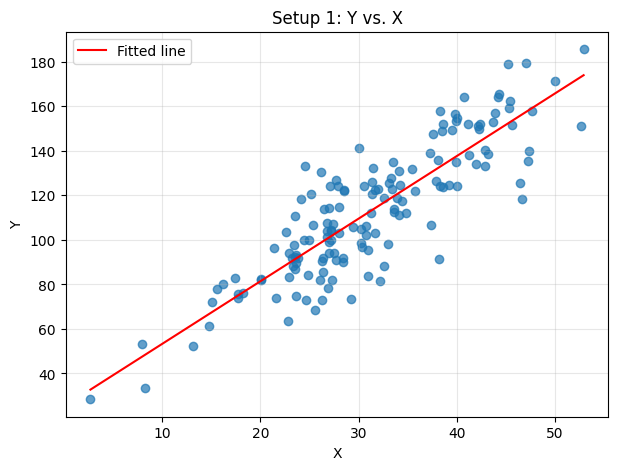

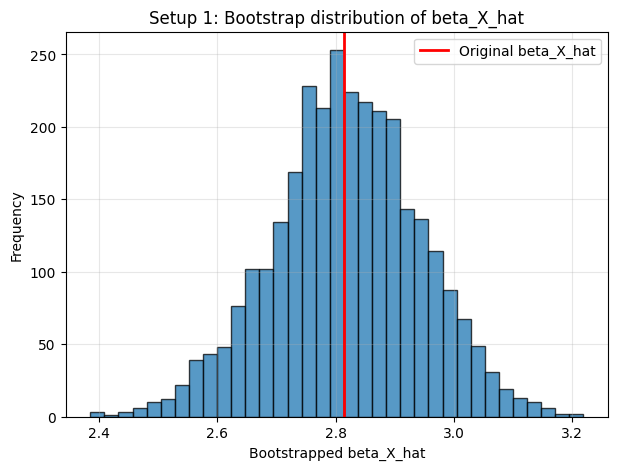


SETUP 2: MULTIPLE REGRESSION WITH X, Y, AND CONFOUNDER W

Now W is rainfall.
More rainfall causes fewer flyers, so W affects X.
More rainfall also affects customers, so W affects Y.

We generate data from:

    Y = intercept + beta_X * X + beta_W * W + error

Then we estimate beta_X and beta_W using:

    Y = intercept_hat + beta_X_hat * X + beta_W_hat * W + residual

The bootstrap approach is the same idea as before.
We repeatedly resample rows and refit the regression Y ~ X + W.

The formula is now matrix-based.
Let X_design be the design matrix with columns:

    [1, X, W]

Then:

    Cov(beta_hat) = sigma_hat^2 * (X_design.T @ X_design)^(-1)

So:

    SE(beta_X_hat) = sqrt(sigma_hat^2 * [(X_design.T @ X_design)^(-1)]_beta_X,beta_X)

This is the multiple-regression version of the same idea.
The relevant denominator is no longer just Var(X).
It depends on how much variation in X remains after accounting for W.
If X and W are highly correlated, the standard error of beta_X_hat become

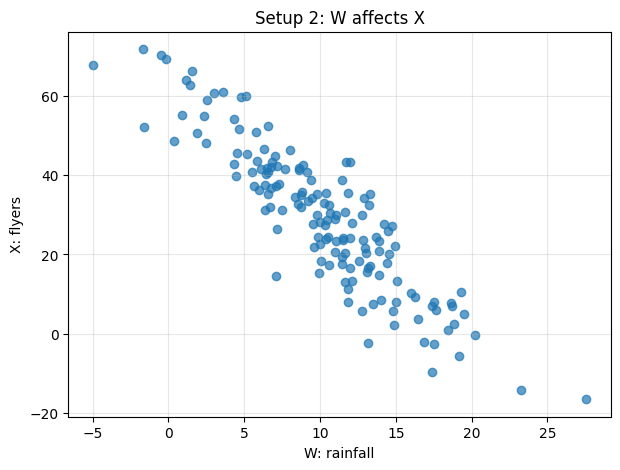

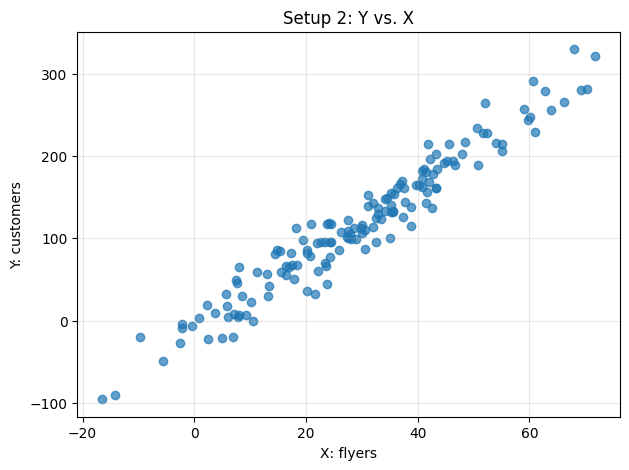

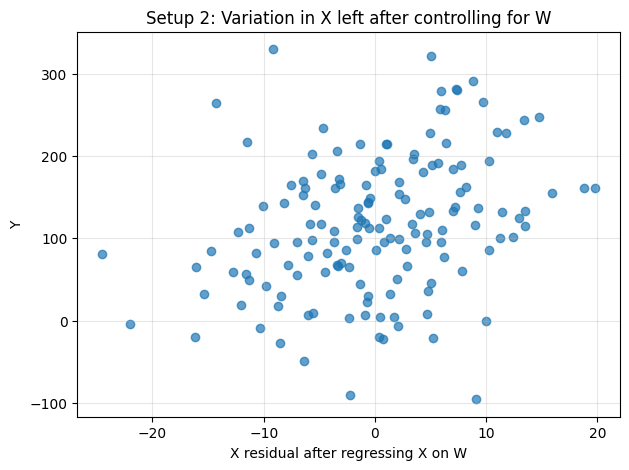

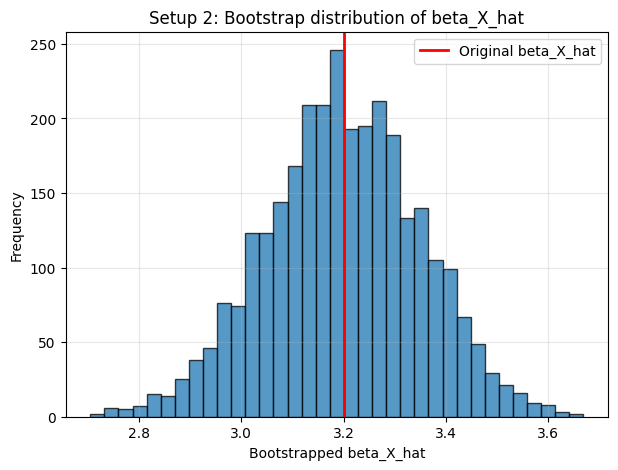

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


def bootstrap_simple_beta_x(x, y, B=3000, seed=1):
    rng = np.random.default_rng(seed)
    n = len(y)
    betas = []

    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        xb = x[idx]
        yb = y[idx]

        model = LinearRegression()
        model.fit(xb.reshape(-1, 1), yb)

        betas.append(model.coef_[0])

    return np.array(betas)


def bootstrap_multiple_beta_x(x, w, y, B=3000, seed=2):
    rng = np.random.default_rng(seed)
    n = len(y)
    beta_x_values = []

    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        xb = x[idx]
        wb = w[idx]
        yb = y[idx]

        model = LinearRegression()
        model.fit(np.column_stack([xb, wb]), yb)

        beta_x_values.append(model.coef_[0])

    return np.array(beta_x_values)


# ============================================================
# SETUP 1: SIMPLE REGRESSION, Y ~ X
# ============================================================

print("=" * 80)
print("SETUP 1: SIMPLE REGRESSION WITH X AND Y ONLY")
print("=" * 80)
print()
print("We generate data from:")
print()
print("    Y = intercept + beta_X * X + error")
print()
print("Then we estimate beta_X with a simple linear regression:")
print()
print("    Y = intercept_hat + beta_X_hat * X + residual")
print()
print("We estimate the standard error of beta_X_hat in two ways:")
print()
print("    1. Bootstrap simulation")
print("    2. The simple-regression formula")
print()
print("The simple-regression standard error formula is:")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 / sum((X_i - X_bar)^2))")
print()
print("Since:")
print()
print("    sum((X_i - X_bar)^2) = (n - 1) * Var_sample(X)")
print()
print("we can write:")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 / ((n - 1) * Var_sample(X)))")
print()
print("For large n, this is approximately:")
print()
print("    SE(beta_X_hat) ≈ sqrt(sigma_hat^2 / (n * Var(X)))")
print()
print("So if Var(X) gets larger, the standard error gets smaller.")
print()


# -----------------------------
# User-adjustable settings
# -----------------------------

seed = 123
rng = np.random.default_rng(seed)

n = 150

true_intercept = 20
true_beta_x = 3

x_mean = 30

x_noise_sd = 10
# USER CAN ADJUST THIS.
# Larger x_noise_sd -> larger Var(X) -> smaller SE(beta_X_hat).
# Smaller x_noise_sd -> smaller Var(X) -> larger SE(beta_X_hat).

y_noise_sd = 15

B = 3000


# -----------------------------
# Generate data
# -----------------------------

x = x_mean + rng.normal(0, x_noise_sd, size=n)
error = rng.normal(0, y_noise_sd, size=n)
y = true_intercept + true_beta_x * x + error


# -----------------------------
# Fit model
# -----------------------------

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

intercept_hat = model.intercept_
beta_x_hat = model.coef_[0]

yhat = model.predict(x.reshape(-1, 1))
residuals = y - yhat


# -----------------------------
# Formula SE
# -----------------------------

sse = np.sum(residuals ** 2)
sigma_hat_squared = sse / (n - 2)

x_bar = np.mean(x)
sum_squared_x_deviations = np.sum((x - x_bar) ** 2)
var_sample_x = np.var(x, ddof=1)

formula_se = np.sqrt(sigma_hat_squared / sum_squared_x_deviations)

formula_se_using_var = np.sqrt(
    sigma_hat_squared / ((n - 1) * var_sample_x)
)

large_n_approx_formula_se = np.sqrt(
    sigma_hat_squared / (n * var_sample_x)
)


# -----------------------------
# Bootstrap SE
# -----------------------------

bootstrap_betas = bootstrap_simple_beta_x(x, y, B=B, seed=456)
bootstrap_se = np.std(bootstrap_betas, ddof=1)


# -----------------------------
# Print results
# -----------------------------

print("Values plugged into the formula:")
print()
print("    n =", n)
print("    sigma_hat^2 =", round(sigma_hat_squared, 4))
print("    X_bar =", round(x_bar, 4))
print("    Var_sample(X) =", round(var_sample_x, 4))
print("    sum((X_i - X_bar)^2) =", round(sum_squared_x_deviations, 4))
print()
print("Formula calculation:")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 / sum((X_i - X_bar)^2))")
print(
    "                   = sqrt("
    + str(round(sigma_hat_squared, 4))
    + " / "
    + str(round(sum_squared_x_deviations, 4))
    + ")"
)
print("                   =", round(formula_se, 4))
print()
print("Equivalent calculation using Var_sample(X):")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 / ((n - 1) * Var_sample(X)))")
print(
    "                   = sqrt("
    + str(round(sigma_hat_squared, 4))
    + " / ("
    + str(n - 1)
    + " * "
    + str(round(var_sample_x, 4))
    + "))"
)
print("                   =", round(formula_se_using_var, 4))
print()
print("Large-n approximation:")
print()
print("    SE(beta_X_hat) ≈ sqrt(sigma_hat^2 / (n * Var_sample(X)))")
print(
    "                   = sqrt("
    + str(round(sigma_hat_squared, 4))
    + " / ("
    + str(n)
    + " * "
    + str(round(var_sample_x, 4))
    + "))"
)
print("                   =", round(large_n_approx_formula_se, 4))
print()
print("Bootstrap estimate:")
print()
print("    Bootstrap SE(beta_X_hat) =", round(bootstrap_se, 4))
print()


summary_1 = pd.DataFrame([
    {"quantity": "true_intercept", "value": true_intercept},
    {"quantity": "true_beta_X", "value": true_beta_x},
    {"quantity": "estimated_intercept", "value": round(intercept_hat, 4)},
    {"quantity": "estimated_beta_X", "value": round(beta_x_hat, 4)},
    {"quantity": "x_noise_sd_user_setting", "value": x_noise_sd},
    {"quantity": "Var_sample(X)", "value": round(var_sample_x, 4)},
    {"quantity": "sigma_hat_squared", "value": round(sigma_hat_squared, 4)},
    {"quantity": "formula_SE_beta_X", "value": round(formula_se, 4)},
    {"quantity": "bootstrap_SE_beta_X", "value": round(bootstrap_se, 4)}
])

print("Summary table:")
print(summary_1.to_string(index=False))
print()


plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.7)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept_hat + beta_x_hat * x_line
plt.plot(x_line, y_line, color="red", label="Fitted line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Setup 1: Y vs. X")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(bootstrap_betas, bins=35, edgecolor="black", alpha=0.75)
plt.axvline(beta_x_hat, color="red", linewidth=2, label="Original beta_X_hat")
plt.xlabel("Bootstrapped beta_X_hat")
plt.ylabel("Frequency")
plt.title("Setup 1: Bootstrap distribution of beta_X_hat")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# SETUP 2: MULTIPLE REGRESSION, Y ~ X + W
# ============================================================

print()
print("=" * 80)
print("SETUP 2: MULTIPLE REGRESSION WITH X, Y, AND CONFOUNDER W")
print("=" * 80)
print()
print("Now W is rainfall.")
print("More rainfall causes fewer flyers, so W affects X.")
print("More rainfall also affects customers, so W affects Y.")
print()
print("We generate data from:")
print()
print("    Y = intercept + beta_X * X + beta_W * W + error")
print()
print("Then we estimate beta_X and beta_W using:")
print()
print("    Y = intercept_hat + beta_X_hat * X + beta_W_hat * W + residual")
print()
print("The bootstrap approach is the same idea as before.")
print("We repeatedly resample rows and refit the regression Y ~ X + W.")
print()
print("The formula is now matrix-based.")
print("Let X_design be the design matrix with columns:")
print()
print("    [1, X, W]")
print()
print("Then:")
print()
print("    Cov(beta_hat) = sigma_hat^2 * (X_design.T @ X_design)^(-1)")
print()
print("So:")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 * [(X_design.T @ X_design)^(-1)]_beta_X,beta_X)")
print()
print("This is the multiple-regression version of the same idea.")
print("The relevant denominator is no longer just Var(X).")
print("It depends on how much variation in X remains after accounting for W.")
print("If X and W are highly correlated, the standard error of beta_X_hat becomes larger.")
print()


# -----------------------------
# User-adjustable settings
# -----------------------------

seed = 789
rng = np.random.default_rng(seed)

n = 150

true_intercept = 80
true_beta_x = 3
true_beta_w = -5

w_mean = 10
w_noise_sd = 5

x_base = 60
rain_effect_on_x = 3

x_noise_sd = 8
# USER CAN ADJUST THIS.
# Larger x_noise_sd -> more variation in X not explained by W -> smaller SE(beta_X_hat).
# Smaller x_noise_sd -> X is more tightly linked to W -> larger SE(beta_X_hat).

y_noise_sd = 15

B = 3000


# -----------------------------
# Generate data
# -----------------------------

w = w_mean + rng.normal(0, w_noise_sd, size=n)

x = (
    x_base
    - rain_effect_on_x * w
    + rng.normal(0, x_noise_sd, size=n)
)

error = rng.normal(0, y_noise_sd, size=n)

y = true_intercept + true_beta_x * x + true_beta_w * w + error


# -----------------------------
# Fit model
# -----------------------------

model = LinearRegression()
model.fit(np.column_stack([x, w]), y)

intercept_hat = model.intercept_
beta_x_hat = model.coef_[0]
beta_w_hat = model.coef_[1]

X_design = np.column_stack([np.ones(n), x, w])

beta_hat_vector = np.array([
    intercept_hat,
    beta_x_hat,
    beta_w_hat
])

yhat = X_design @ beta_hat_vector
residuals = y - yhat


# -----------------------------
# Formula SE
# -----------------------------

sse = np.sum(residuals ** 2)
sigma_hat_squared = sse / (n - 3)

xtx = X_design.T @ X_design
xtx_inv = np.linalg.inv(xtx)

cov_beta_hat = sigma_hat_squared * xtx_inv

formula_se_beta_x = np.sqrt(cov_beta_hat[1, 1])
formula_se_beta_w = np.sqrt(cov_beta_hat[2, 2])


# -----------------------------
# Bootstrap SE
# -----------------------------

bootstrap_betas_x = bootstrap_multiple_beta_x(x, w, y, B=B, seed=999)
bootstrap_se_beta_x = np.std(bootstrap_betas_x, ddof=1)


# -----------------------------
# Extra diagnostic: residual variation in X after controlling W
# -----------------------------

model_x_on_w = LinearRegression()
model_x_on_w.fit(w.reshape(-1, 1), x)

x_hat_from_w = model_x_on_w.predict(w.reshape(-1, 1))
x_residual_after_w = x - x_hat_from_w

sum_squared_x_after_w = np.sum(x_residual_after_w ** 2)
var_x_after_w = np.var(x_residual_after_w, ddof=1)

formula_se_beta_x_using_residualized_x = np.sqrt(
    sigma_hat_squared / sum_squared_x_after_w
)


# -----------------------------
# Print results
# -----------------------------

print("Values plugged into the matrix formula:")
print()
print("    n =", n)
print("    number of fitted parameters = 3")
print("    sigma_hat^2 = SSE / (n - 3) =", round(sigma_hat_squared, 4))
print()
print("    X_design has columns [1, X, W]")
print()
print("    X_design.T @ X_design =")
print(pd.DataFrame(
    xtx,
    index=["1", "X", "W"],
    columns=["1", "X", "W"]
).round(4).to_string())
print()
print("    (X_design.T @ X_design)^(-1) =")
print(pd.DataFrame(
    xtx_inv,
    index=["intercept", "beta_X", "beta_W"],
    columns=["intercept", "beta_X", "beta_W"]
).round(8).to_string())
print()
print("Formula calculation:")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 * [(X_design.T @ X_design)^(-1)]_beta_X,beta_X)")
print(
    "                   = sqrt("
    + str(round(sigma_hat_squared, 4))
    + " * "
    + str(round(xtx_inv[1, 1], 8))
    + ")"
)
print("                   =", round(formula_se_beta_x, 4))
print()
print("A useful equivalent view uses residualized X.")
print("First regress X on W and keep the residuals.")
print("Those residuals are the part of X not explained by W.")
print()
print("Then:")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 / sum(X_residual_after_W^2))")
print()
print("Values:")
print()
print("    Var(X) =", round(np.var(x, ddof=1), 4))
print("    Var(W) =", round(np.var(w, ddof=1), 4))
print("    Corr(X, W) =", round(np.corrcoef(x, w)[0, 1], 4))
print("    Var(X residual after W) =", round(var_x_after_w, 4))
print("    sum(X_residual_after_W^2) =", round(sum_squared_x_after_w, 4))
print()
print("Residualized-X calculation:")
print()
print("    SE(beta_X_hat) = sqrt(sigma_hat^2 / sum(X_residual_after_W^2))")
print(
    "                   = sqrt("
    + str(round(sigma_hat_squared, 4))
    + " / "
    + str(round(sum_squared_x_after_w, 4))
    + ")"
)
print("                   =", round(formula_se_beta_x_using_residualized_x, 4))
print()
print("Bootstrap estimate:")
print()
print("    Bootstrap SE(beta_X_hat) =", round(bootstrap_se_beta_x, 4))
print()


summary_2 = pd.DataFrame([
    {"quantity": "true_intercept", "value": true_intercept},
    {"quantity": "true_beta_X", "value": true_beta_x},
    {"quantity": "true_beta_W", "value": true_beta_w},
    {"quantity": "estimated_intercept", "value": round(intercept_hat, 4)},
    {"quantity": "estimated_beta_X", "value": round(beta_x_hat, 4)},
    {"quantity": "estimated_beta_W", "value": round(beta_w_hat, 4)},
    {"quantity": "x_noise_sd_user_setting", "value": x_noise_sd},
    {"quantity": "rain_effect_on_x", "value": rain_effect_on_x},
    {"quantity": "Var(X)", "value": round(np.var(x, ddof=1), 4)},
    {"quantity": "Var(X residual after W)", "value": round(var_x_after_w, 4)},
    {"quantity": "Corr(X, W)", "value": round(np.corrcoef(x, w)[0, 1], 4)},
    {"quantity": "sigma_hat_squared", "value": round(sigma_hat_squared, 4)},
    {"quantity": "formula_SE_beta_X", "value": round(formula_se_beta_x, 4)},
    {"quantity": "bootstrap_SE_beta_X", "value": round(bootstrap_se_beta_x, 4)},
    {"quantity": "formula_SE_beta_W", "value": round(formula_se_beta_w, 4)}
])

print("Summary table:")
print(summary_2.to_string(index=False))
print()


plt.figure(figsize=(7, 5))
plt.scatter(w, x, alpha=0.7)
plt.xlabel("W: rainfall")
plt.ylabel("X: flyers")
plt.title("Setup 2: W affects X")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("X: flyers")
plt.ylabel("Y: customers")
plt.title("Setup 2: Y vs. X")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(x_residual_after_w, y, alpha=0.7)
plt.xlabel("X residual after regressing X on W")
plt.ylabel("Y")
plt.title("Setup 2: Variation in X left after controlling for W")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(bootstrap_betas_x, bins=35, edgecolor="black", alpha=0.75)
plt.axvline(beta_x_hat, color="red", linewidth=2, label="Original beta_X_hat")
plt.xlabel("Bootstrapped beta_X_hat")
plt.ylabel("Frequency")
plt.title("Setup 2: Bootstrap distribution of beta_X_hat")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Transforming X

## Log(X + 1)
## Sqrt(X)
## Asinh(X)
## Winsorizing

In [ ]:
X = [1, 2, 4, 8]
Y = [1, 2, 3, 4]

#log2(X) = 0, 1, 2, 3
#Y = 1, 2, 3, 4

#Y = log2(X) + 1

In [ ]:
log2(Y) = beta * log2(X) + intercept
Y = X^beta * 2^intercept

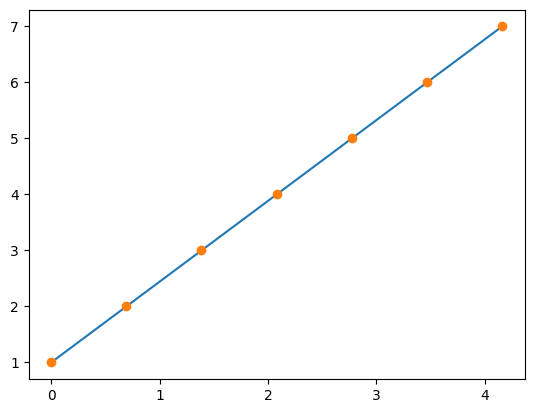

In [18]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
X = np.array([1, 2, 4, 8, 16, 32, 64])
Y = np.array([1, 2, 3, 4, 5, 6, 7])
X = np.log(X)

results = sm.OLS(Y, sm.add_constant(X)).fit()
plt.plot(X, results.params[0] + X * results.params[1])
plt.plot(X, Y, "o")

SCENARIO: TRANSFORMING X

A campus coffee cart tracks advertising spend and daily sales.

X = dollars spent on ads that day
Y = cups of coffee sold that day

The key idea is diminishing returns:
Going from $0 to $20 of advertising may help a lot.
Going from $500 to $520 may barely matter.

So the relationship between raw X and Y is curved.
A transformation of X may make the relationship more linear.

We will compare these one-variable models:

    1. Y ~ X
    2. Y ~ ln(X + 1)
    3. Y ~ sqrt(X)
    4. Y ~ asinh(X)
       where asinh(X) = ln(X + sqrt(1 + X**2))
    5. Y ~ winsorized X

Winsorizing means:
Take every observation above the upper percentile and replace it with the upper-percentile value.
Optionally, take every observation below the lower percentile and replace it with the lower-percentile value.

MODEL COMPARISON
           model  intercept_hat  slope_hat    RMSE
   Y ~ ln(X + 1)        43.2836    26.7877 12.0220
    Y ~ asinh(X)        34.1320    24.8832 12.0782
     Y ~ 

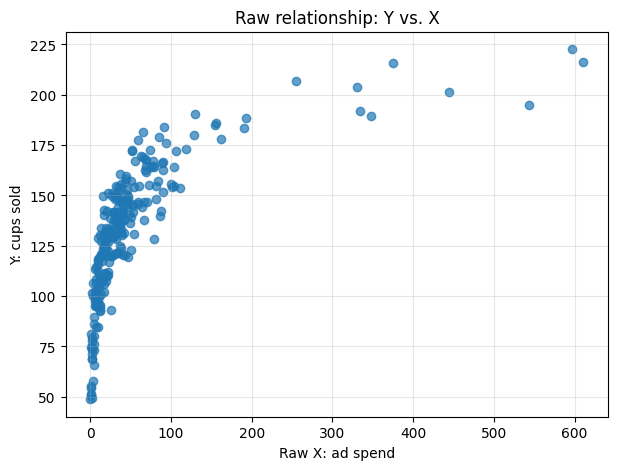

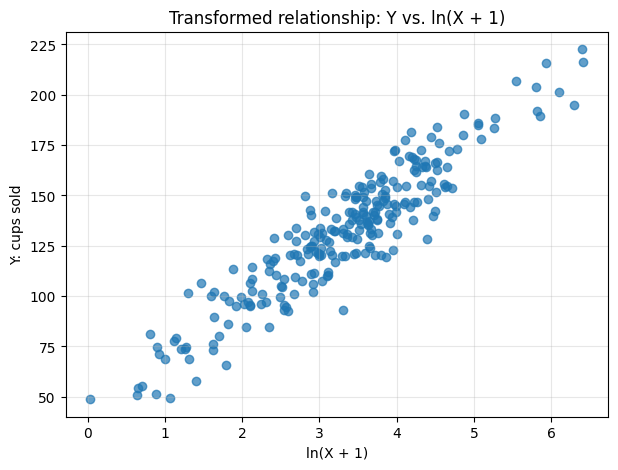

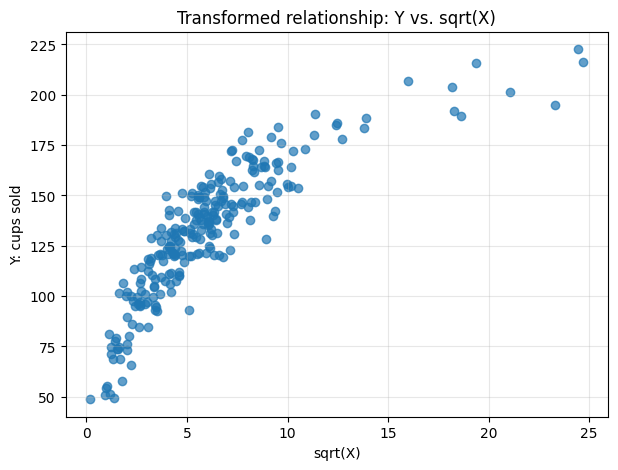

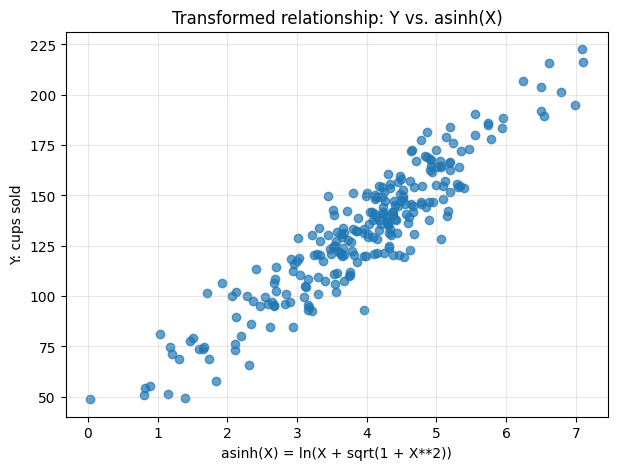

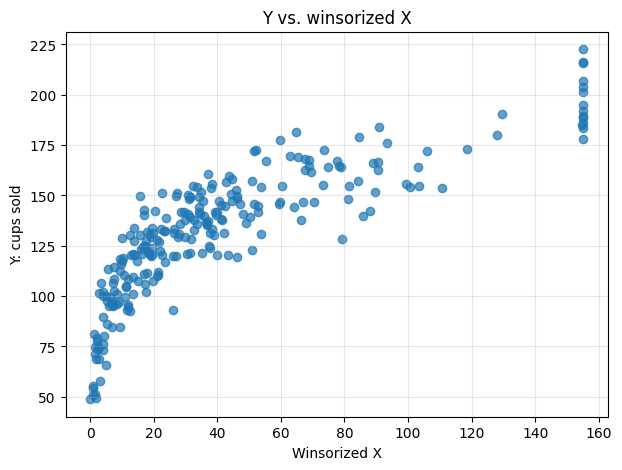

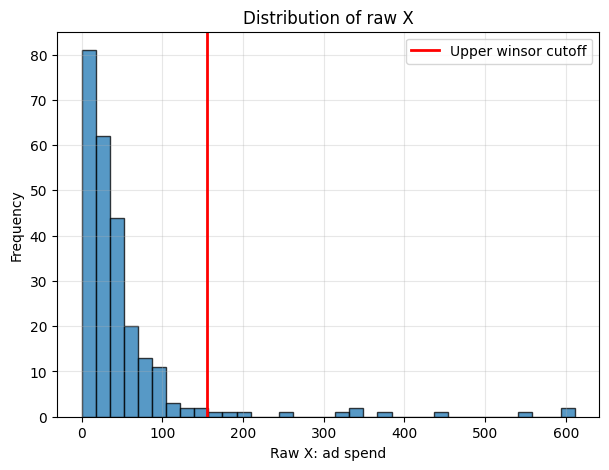

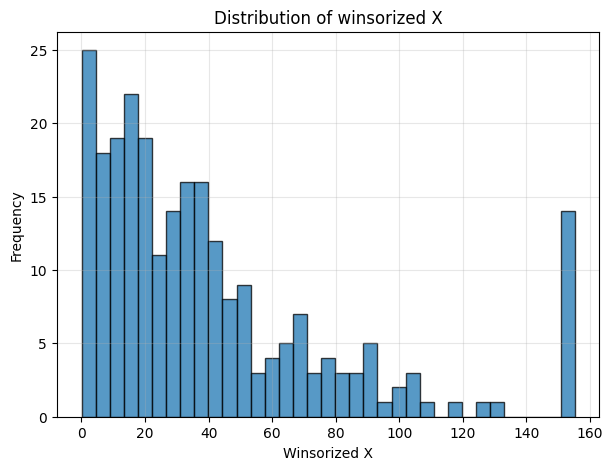

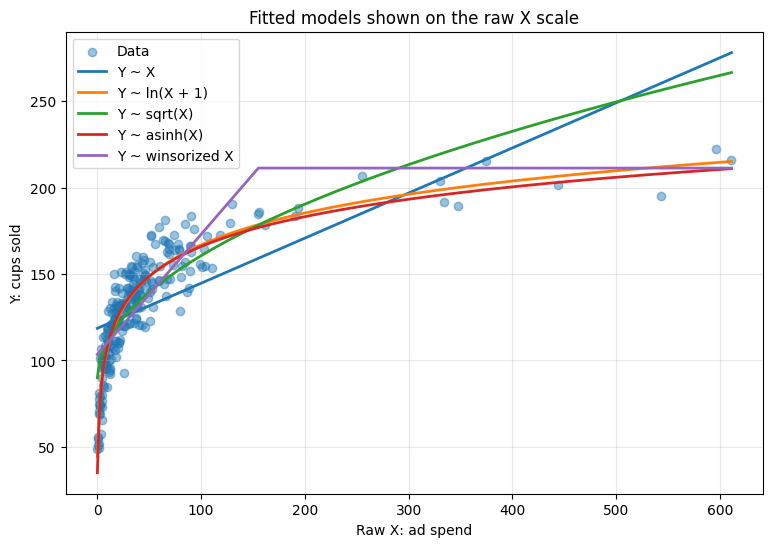

INTERPRETATION

Raw X:
    Useful when the relationship is approximately linear.

ln(X + 1):
    Useful for positive, right-skewed X with diminishing returns.
    The +1 allows X = 0.

sqrt(X):
    Also useful for positive skew and diminishing returns, but usually less aggressive than log.

asinh(X):
    Similar to log for large positive X, but also works with X = 0 and negative values.
    asinh(X) = ln(X + sqrt(1 + X**2)).

Winsorized X:
    Useful when extreme X values have too much leverage.
    It does not create a curved transformation; it caps extreme values.



In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


def asinh_transform(x):
    return np.log(x + np.sqrt(1 + x**2))


def winsorize(x, lower_percentile=1, upper_percentile=99):
    lower = np.percentile(x, lower_percentile)
    upper = np.percentile(x, upper_percentile)
    return np.clip(x, lower, upper), lower, upper


def fit_one_feature_model(feature, y):
    model = LinearRegression()
    model.fit(feature.reshape(-1, 1), y)

    yhat = model.predict(feature.reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(y, yhat))

    return model, yhat, rmse


# ============================================================
# Scenario: Diminishing returns from advertising spend
# ============================================================

print("=" * 80)
print("SCENARIO: TRANSFORMING X")
print("=" * 80)
print()
print("A campus coffee cart tracks advertising spend and daily sales.")
print()
print("X = dollars spent on ads that day")
print("Y = cups of coffee sold that day")
print()
print("The key idea is diminishing returns:")
print("Going from $0 to $20 of advertising may help a lot.")
print("Going from $500 to $520 may barely matter.")
print()
print("So the relationship between raw X and Y is curved.")
print("A transformation of X may make the relationship more linear.")
print()
print("We will compare these one-variable models:")
print()
print("    1. Y ~ X")
print("    2. Y ~ ln(X + 1)")
print("    3. Y ~ sqrt(X)")
print("    4. Y ~ asinh(X)")
print("       where asinh(X) = ln(X + sqrt(1 + X**2))")
print("    5. Y ~ winsorized X")
print()
print("Winsorizing means:")
print("Take every observation above the upper percentile and replace it with the upper-percentile value.")
print("Optionally, take every observation below the lower percentile and replace it with the lower-percentile value.")
print()


# -----------------------------
# User-adjustable settings
# -----------------------------

seed = 123
rng = np.random.default_rng(seed)

n = 250

true_intercept = 40
true_beta_log = 28

noise_sd = 12

# X is skewed, like spending data often is.
# Most days have small/moderate spending, a few days have very large spending.
x_scale = 45
x = rng.exponential(scale=x_scale, size=n)

# Add a few extreme advertising-spend days.
n_outliers = 8
outlier_indices = rng.choice(n, size=n_outliers, replace=False)
x[outlier_indices] = x[outlier_indices] + rng.uniform(250, 600, size=n_outliers)

# True relationship uses ln(X + 1), not raw X.
error = rng.normal(0, noise_sd, size=n)
y = true_intercept + true_beta_log * np.log(x + 1) + error

# Winsorizing choices.
lower_percentile = 0
upper_percentile = 95


# -----------------------------
# Create transformed features
# -----------------------------

x_log = np.log(x + 1)
x_sqrt = np.sqrt(x)
x_asinh = asinh_transform(x)
x_winsorized, winsor_lower, winsor_upper = winsorize(
    x,
    lower_percentile=lower_percentile,
    upper_percentile=upper_percentile
)


# -----------------------------
# Fit models
# -----------------------------

models = {}

models["raw X"] = fit_one_feature_model(x, y)
models["ln(X + 1)"] = fit_one_feature_model(x_log, y)
models["sqrt(X)"] = fit_one_feature_model(x_sqrt, y)
models["asinh(X)"] = fit_one_feature_model(x_asinh, y)
models["winsorized X"] = fit_one_feature_model(x_winsorized, y)


# -----------------------------
# Results table
# -----------------------------

results = []

for name, (model, yhat, rmse) in models.items():
    results.append({
        "model": "Y ~ " + name,
        "intercept_hat": round(model.intercept_, 4),
        "slope_hat": round(model.coef_[0], 4),
        "RMSE": round(rmse, 4)
    })

results_table = pd.DataFrame(results).sort_values("RMSE")

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(results_table.to_string(index=False))
print()
print("Lower RMSE means the model fits the data better.")
print("Because the true relationship was generated using ln(X + 1),")
print("the model using ln(X + 1) should usually be one of the best.")
print()


print("=" * 80)
print("WINSORIZING DETAILS")
print("=" * 80)
print()
print("lower_percentile =", lower_percentile)
print("upper_percentile =", upper_percentile)
print("winsor_lower =", round(winsor_lower, 4))
print("winsor_upper =", round(winsor_upper, 4))
print()
print("Any X above", round(winsor_upper, 4), "was replaced by", round(winsor_upper, 4))
print("Any X below", round(winsor_lower, 4), "was replaced by", round(winsor_lower, 4))
print()


# -----------------------------
# Plots
# -----------------------------

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Raw X: ad spend")
plt.ylabel("Y: cups sold")
plt.title("Raw relationship: Y vs. X")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(x_log, y, alpha=0.7)
plt.xlabel("ln(X + 1)")
plt.ylabel("Y: cups sold")
plt.title("Transformed relationship: Y vs. ln(X + 1)")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(x_sqrt, y, alpha=0.7)
plt.xlabel("sqrt(X)")
plt.ylabel("Y: cups sold")
plt.title("Transformed relationship: Y vs. sqrt(X)")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(x_asinh, y, alpha=0.7)
plt.xlabel("asinh(X) = ln(X + sqrt(1 + X**2))")
plt.ylabel("Y: cups sold")
plt.title("Transformed relationship: Y vs. asinh(X)")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(x_winsorized, y, alpha=0.7)
plt.xlabel("Winsorized X")
plt.ylabel("Y: cups sold")
plt.title("Y vs. winsorized X")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(x, bins=35, edgecolor="black", alpha=0.75)
plt.axvline(winsor_upper, color="red", linewidth=2, label="Upper winsor cutoff")
plt.xlabel("Raw X: ad spend")
plt.ylabel("Frequency")
plt.title("Distribution of raw X")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7, 5))
plt.hist(x_winsorized, bins=35, edgecolor="black", alpha=0.75)
plt.xlabel("Winsorized X")
plt.ylabel("Frequency")
plt.title("Distribution of winsorized X")
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# Optional: show fitted curves on raw X scale
# -----------------------------

x_grid = np.linspace(x.min(), x.max(), 300)

x_grid_log = np.log(x_grid + 1)
x_grid_sqrt = np.sqrt(x_grid)
x_grid_asinh = asinh_transform(x_grid)
x_grid_winsorized = np.clip(x_grid, winsor_lower, winsor_upper)

raw_model = models["raw X"][0]
log_model = models["ln(X + 1)"][0]
sqrt_model = models["sqrt(X)"][0]
asinh_model = models["asinh(X)"][0]
winsor_model = models["winsorized X"][0]

plt.figure(figsize=(9, 6))
plt.scatter(x, y, alpha=0.45, label="Data")

plt.plot(
    x_grid,
    raw_model.predict(x_grid.reshape(-1, 1)),
    label="Y ~ X",
    linewidth=2
)

plt.plot(
    x_grid,
    log_model.predict(x_grid_log.reshape(-1, 1)),
    label="Y ~ ln(X + 1)",
    linewidth=2
)

plt.plot(
    x_grid,
    sqrt_model.predict(x_grid_sqrt.reshape(-1, 1)),
    label="Y ~ sqrt(X)",
    linewidth=2
)

plt.plot(
    x_grid,
    asinh_model.predict(x_grid_asinh.reshape(-1, 1)),
    label="Y ~ asinh(X)",
    linewidth=2
)

plt.plot(
    x_grid,
    winsor_model.predict(x_grid_winsorized.reshape(-1, 1)),
    label="Y ~ winsorized X",
    linewidth=2
)

plt.xlabel("Raw X: ad spend")
plt.ylabel("Y: cups sold")
plt.title("Fitted models shown on the raw X scale")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("=" * 80)
print("INTERPRETATION")
print("=" * 80)
print()
print("Raw X:")
print("    Useful when the relationship is approximately linear.")
print()
print("ln(X + 1):")
print("    Useful for positive, right-skewed X with diminishing returns.")
print("    The +1 allows X = 0.")
print()
print("sqrt(X):")
print("    Also useful for positive skew and diminishing returns, but usually less aggressive than log.")
print()
print("asinh(X):")
print("    Similar to log for large positive X, but also works with X = 0 and negative values.")
print("    asinh(X) = ln(X + sqrt(1 + X**2)).")
print()
print("Winsorized X:")
print("    Useful when extreme X values have too much leverage.")
print("    It does not create a curved transformation; it caps extreme values.")
print()